## INSTALL

In [ ]:
import sys

REQUIRED_VERSION = (3, 11, 9)
current_version  = sys.version_info[:3]

if current_version != REQUIRED_VERSION:
    version_parts = []
    for version_number in current_version:
        version_parts.append(str(version_number))
    version_string = '.'.join(version_parts)
    raise RuntimeError(
        f"Wrong Python version. Expected 3.11.9, "
        f"got {version_string}. "
        "Make sure the correct kernel is selected."
    )

ok_parts = []
for version_number in current_version:
    ok_parts.append(str(version_number))
ok_version_string = '.'.join(ok_parts)
print(f"Python {ok_version_string} OK")

#%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall
#%pip install pandas numpy Pillow tqdm scikit-learn xgboost timm
%pip install timm lightgbm catboost seaborn

## IMPORTS

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    cross_val_score, ParameterGrid
)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
import open_clip

c:\Users\TheRe\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MODEL SELECTOR

In [2]:
# we load the hugging face token to get fast download, make sure to create a .env file and put your token in there
with open('.env') as env_file:
    for env_line in env_file:
        if '=' in env_line and not env_line.startswith('#'):
            env_line_stripped = env_line.strip()
            env_key, env_value = env_line_stripped.split('=', 1)
            os.environ[env_key] = env_value

hf_token_found = os.environ.get('HF_TOKEN')
if hf_token_found:
    print('HF_TOKEN loaded')
else:
    print('WARNING: HF_TOKEN not found in .env')

HF_TOKEN loaded


In [3]:
# --- Model Selector -----------------------------------------------------------
FEATURE_EXTRACTOR = 'convnextv2'
USE_FINETUNED     = True   # True after running FINE-TUNING
N_FOLDS = 2 # Cross-validation folds (higher = more robust, but slower train times)
# -----------------------------------------------------------------------------


## DEFINITIONS

In [4]:
# =============================================================================
# DEVICE
# =============================================================================
import timm

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')

# =============================================================================
# BACKBONE MODEL LOADING  (ConvNeXtV2-Huge, 2816-d)
# =============================================================================

backbone_model = timm.create_model('convnextv2_huge.fcmae_ft_in22k_in1k_384', pretrained=True, num_classes=0)
backbone_model = backbone_model.to(device)
backbone_model = backbone_model.eval()

data_config = timm.data.resolve_model_data_config(backbone_model)
backbone_preprocess = timm.data.create_transform(**data_config, is_training=False)

def encode(batch):
    batch_on_device = batch.to(device)
    raw_output = backbone_model(batch_on_device)
    float_output = raw_output.float()
    cpu_output = float_output.cpu()
    return cpu_output

feature_file_suffix = '_convnextv2'
print(f'Backbone: convnextv2  |  suffix: {feature_file_suffix!r}  |  device: {device}')

# =============================================================================
# IMAGE SAVING HELPERS
# =============================================================================

def save_images(image_dir, output_file, has_labels=True):

    image_tensors = []
    labels        = []
    file_paths    = []

    if has_labels: # train set has labels

        # count the classes
        class_names = sorted(os.listdir(image_dir))
        class_to_index = {}
        for index, name in enumerate(class_names):
            class_to_index[name] = index

        total_images = 0
        for cls in class_names:
            cls_path = os.path.join(image_dir, cls)
            if os.path.isdir(cls_path):
                cls_file_count = len(os.listdir(cls_path))
                total_images = total_images + cls_file_count

        count = 0

        # for each class
        for class_name in class_names:
            class_folder = os.path.join(image_dir, class_name)

            # for instance in class folder
            for filename in os.listdir(class_folder):

                # skip non images
                filename_lower = filename.lower()
                if not filename_lower.endswith(('.png')):
                    continue

                image_path = os.path.join(class_folder, filename)

                # open the image and convert to RGB (just incase), and use our model's preprocess function
                raw_image = Image.open(image_path)
                opened_image = raw_image.convert('RGB')
                preprocessed_image = backbone_preprocess(opened_image)
                image_tensors.append(preprocessed_image)
                labels.append(class_to_index[class_name])

                file_paths.append(image_path)

                count += 1
                print(f'{count}/{total_images}', end='\r')

        # save images as one tensor file, makes it easier later
        stacked_tensors = torch.stack(image_tensors)
        label_tensor = torch.tensor(labels)
        torch.save({
            'tensors':        stacked_tensors,
            'labels':         label_tensor,
            'paths':          file_paths,
            'class_to_index': class_to_index,
        }, output_file)

    else: # test set has no assigned labels

        # count the images
        all_dir_files = os.listdir(image_dir)
        image_files = []
        for filename in all_dir_files:
            filename_lower = filename.lower()
            if filename_lower.endswith(('.jpg', '.jpeg', '.png')):
                image_files.append(filename)
        total_images = len(image_files)

        # for each image
        for i, filename in enumerate(image_files, start=1):

            # open the image and convert to RGB (just incase), and use our model's preprocess function
            image_path = os.path.join(image_dir, filename)
            raw_image = Image.open(image_path)
            opened_image = raw_image.convert('RGB')
            preprocessed_image = backbone_preprocess(opened_image)
            image_tensors.append(preprocessed_image)

            file_paths.append(image_path)

            print(f'{i}/{total_images}', end='\r')

        # save image as one tensor file
        stacked_tensors = torch.stack(image_tensors)
        torch.save({'tensors': stacked_tensors, 'paths': file_paths}, output_file)

    print(f'\nSaved {len(image_tensors)} images to {output_file}')

# This function passes every image through our backbone, and saves the feature/embedding vectors
def extract(input_file, output_file):

    # load our saved preprocessed images
    data         = torch.load(input_file, weights_only=False)
    images       = data['tensors']

    total_images = len(images)
    feature_list = []

    # set backbone model to pass forward mode
    with torch.no_grad():

        # for every image
        for i, image in enumerate(images, start=1):

            # pass image through model
            unsqueezed_image = image.unsqueeze(0)
            encoded_output = encode(unsqueezed_image)
            squeezed_output = encoded_output.squeeze()
            feature_array = squeezed_output.numpy()
            feature_list.append(feature_array)
            print(f'{i}/{total_images}', end='\r')

    # save the features as one tensor
    features = np.array(feature_list)
    save_dict = {}
    for existing_key, existing_value in data.items():
        save_dict[existing_key] = existing_value
    save_dict['features'] = features
    torch.save(save_dict, output_file)

    print(f'\nExtracted {features.shape} -> saved to {output_file}')

Device: cuda
Backbone: convnextv2  |  suffix: '_convnextv2'  |  device: cuda


In [5]:
# =============================================================================
# METRICS HELPER
# =============================================================================

# Return a dictionary of all the basic metrics
def compute_classification_metrics(true_labels, predicted_labels):

    # get number of classes, and number of instances in each class
    unique_classes, samples_per_class = np.unique(true_labels, return_counts=True)

    class_balance = {}
    for cls, n in zip(unique_classes, samples_per_class):
        class_key = int(cls)
        class_pct = round(100 * n / len(true_labels), 1)
        class_balance[class_key] = class_pct

    return {
        'accuracy':      accuracy_score(true_labels, predicted_labels),
        'f1':            f1_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'precision':     precision_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'recall':        recall_score(true_labels, predicted_labels, average='weighted', zero_division=0),
        'class_balance': class_balance,
    }

# print the mean +/- std for each metric across all folds
def print_cross_validation_report(model_name, fold_metrics_list):

    print(f'--- {model_name} ---')
    for metric_name in ('accuracy', 'f1', 'precision', 'recall'):
        values = []
        for fold_metrics in fold_metrics_list:
            values.append(fold_metrics[metric_name])
        mean_value = np.mean(values)
        std_value  = np.std(values)
        print(f'  {metric_name:<9}: {mean_value:.4f} +/- {std_value:.4f}')

    print('  class balance:')
    for cls, pct in fold_metrics_list[0]['class_balance'].items():
        print(f'    class {cls}: {pct}%')

    print()


# =============================================================================
# MLP MODEL
# =============================================================================

# A simple implementation of an MLP object, we can use different activations and layers and dropouts
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_layers=(256, 128),
                 activation=nn.ReLU, dropout=0.0):

        parent_class = super()
        parent_class.__init__()
        network_layers     = []
        current_layer_size = input_size

        # construct the layers
        for layer_output_size in hidden_layers:
            network_layers.append(nn.Linear(current_layer_size, layer_output_size))
            network_layers.append(activation())

            if dropout > 0:
                network_layers.append(nn.Dropout(dropout))

            current_layer_size = layer_output_size

        # attach the output layer
        network_layers.append(nn.Linear(current_layer_size, num_classes))
        self.network = nn.Sequential(*network_layers)

    # parse input thru network
    def forward(self, input_tensor):
        return self.network(input_tensor)

# =============================================================================
# CLASSIFIER FUNCTIONS
# =============================================================================


def train_logistic_regression(training_features, training_labels,
                               validation_features, validation_labels,
                               regularisation_strength=1.0):

    training_features_array   = np.asarray(training_features, np.float64)
    training_labels_array     = np.asarray(training_labels,   np.int64)
    validation_features_array = np.asarray(validation_features, np.float64)

    model = LogisticRegression(C=regularisation_strength, max_iter=2000, random_state=42)
    model.fit(training_features_array, training_labels_array)
    predictions = model.predict(validation_features_array)

    return model, compute_classification_metrics(validation_labels, predictions)


def train_support_vector_machine(training_features, training_labels,
                                  validation_features, validation_labels,
                                  kernel='rbf', regularisation_strength=1.0,
                                  gamma='scale'):
    training_features_array   = np.asarray(training_features, np.float64)
    training_labels_array     = np.asarray(training_labels,   np.int64)
    validation_features_array = np.asarray(validation_features, np.float64)

    model = SVC(
        kernel=kernel, C=regularisation_strength, gamma=gamma,
        decision_function_shape='ovr', random_state=42,
    )
    model.fit(training_features_array, training_labels_array)
    predictions = model.predict(validation_features_array)

    return model, compute_classification_metrics(validation_labels, predictions)

# Training of MLP, we use early stopping so we dont overfit and also to cut down training time
def train_multilayer_perceptron(training_features, training_labels,
                                 validation_features, validation_labels,
                                 hidden_layers=(256, 128), activation=nn.ReLU,
                                 dropout=0.0, epochs=200, learning_rate=1e-3):

    if torch.cuda.is_available():
        compute_device = 'cuda'
    else:
        compute_device = 'cpu'
    number_of_classes = len(np.unique(training_labels))

    # Move data to tensors on the compute device
    training_features_array   = np.asarray(training_features,   np.float32)
    training_labels_array     = np.asarray(training_labels,     np.int64)
    validation_features_array = np.asarray(validation_features, np.float32)
    validation_labels_array   = np.asarray(validation_labels,   np.int64)

    training_input     = torch.tensor(training_features_array)
    training_input     = training_input.to(compute_device)
    training_targets   = torch.tensor(training_labels_array)
    training_targets   = training_targets.to(compute_device)
    validation_input   = torch.tensor(validation_features_array)
    validation_input   = validation_input.to(compute_device)
    validation_targets = torch.tensor(validation_labels_array)
    validation_targets = validation_targets.to(compute_device)

    # Create the loader
    training_dataset = TensorDataset(training_input, training_targets)
    training_data_loader = DataLoader(
        training_dataset,
        batch_size=512, shuffle=True
    )

    # Create the actual model with a set seed, optimiser and loss function
    torch.manual_seed(42)
    mlp_instance  = MLP(training_input.shape[1], number_of_classes,
                        hidden_layers, activation, dropout)
    model         = mlp_instance.to(compute_device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    # variables for early stopping
    best_val_loss              = float('inf')
    best_weights               = None
    epochs_without_improvement = 0

    # training loop
    for epoch in range(epochs):

        # Training pass
        model.train()
        for input_batch, target_batch in training_data_loader:
            optimizer.zero_grad()
            batch_output = model(input_batch)
            loss = loss_function(batch_output, target_batch)
            loss.backward()
            optimizer.step()

        # Validation check
        model.eval()
        with torch.no_grad():
            val_logits = model(validation_input)
            val_loss_tensor = loss_function(val_logits, validation_targets)
            val_loss = val_loss_tensor.item()

        # Save best weights and count how long we've been stuck
        if val_loss < best_val_loss:
            best_val_loss              = val_loss
            best_weights               = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 25:
                break  # early stopping

    # get best weights
    model.load_state_dict(best_weights)
    model.eval()

    # get our predictions
    with torch.no_grad():
        val_logits   = model(validation_input)
        val_argmax   = val_logits.argmax(dim=1)
        val_cpu      = val_argmax.cpu()
        predictions  = val_cpu.numpy()

    return model, compute_classification_metrics(validation_labels, predictions)


def train_knn_classifier(training_features, training_labels,
                          validation_features, validation_labels,
                          number_of_neighbours=10, distance_metric='cosine'):
    # Cosine distance is the default because DINOv2/BioCLIP embeddings
    # live on a roughly hyper-spherical surface where cosine similarity works well.

    training_features_array   = np.asarray(training_features, np.float64)
    training_labels_array     = np.asarray(training_labels,   np.int64)
    validation_features_array = np.asarray(validation_features, np.float64)

    model = KNeighborsClassifier(
        n_neighbors=number_of_neighbours, metric=distance_metric, n_jobs=-1
    )
    model.fit(training_features_array, training_labels_array)
    predictions = model.predict(validation_features_array)

    return model, compute_classification_metrics(validation_labels, predictions)

# =============================================================================
# SHARED PCA PIPELINE HELPER
# =============================================================================

# Fit a scaler and a PCA on train set, then apply them on test set
def apply_scaler_and_pca(train_feat, val_feat, n_components):

    # Standardize
    scaler     = StandardScaler()
    train_feat = scaler.fit_transform(train_feat) # fit
    val_feat   = scaler.transform(val_feat) # apply

    # PCA
    pca        = PCA(n_components=n_components, svd_solver='auto')
    train_feat = pca.fit_transform(train_feat)
    train_feat = train_feat.astype(np.float32) # fit
    val_feat   = pca.transform(val_feat)
    val_feat   = val_feat.astype(np.float32) # apply

    return train_feat, val_feat

In [6]:
# =============================================================================
# FINE-TUNE HELPER FUNCTIONS
# =============================================================================
# These are called by finetune() below.  Breaking them out keeps finetune()
# readable and makes each step easy to test or override independently.
# Fine-tuning applies to ConvNeXtV2 only; BioCLIP is always frozen.


def freeze_and_unfreeze_backbone(backbone_model, num_stages):
    """Freeze all backbone parameters, then unfreeze the last num_stages
    ConvNeXtV2 conv stages plus the head (norm + pool).
    Returns (stages, num_stages_used)."""
    for param in backbone_model.parameters():
        param.requires_grad = False

    stages         = list(backbone_model.stages)   # 4 conv stages
    default_stages = 1

    if num_stages is None:
        num_stages = default_stages

    for stage in stages[-num_stages:]:
        for param in stage.parameters():
            param.requires_grad = True
    for param in backbone_model.head.parameters():
        param.requires_grad = True

    trainable = 0
    for param in backbone_model.parameters():
        if param.requires_grad:
            trainable = trainable + param.numel()

    total = 0
    for param in backbone_model.parameters():
        total = total + param.numel()

    print(f'Trainable: {trainable:,}/{total:,} '
          f'({100*trainable/total:.1f}%)  '
          f'[{num_stages}/{len(stages)} stages unfrozen]')

    return stages, num_stages


def build_prefix_and_suffix(backbone_model, stages, num_stages):
    """Build two callables that split ConvNeXtV2 at the freeze boundary.

    frozen_prefix_fn(batch) -- stem + frozen conv stages.
    trainable_suffix_fn(x)  -- unfrozen stages + head -> feature vector (B, 2816).
    """
    def frozen_prefix_fn(batch):
        x = backbone_model.stem(batch)
        for stage in stages[:-num_stages]:
            x = stage(x)
        return x

    def trainable_suffix_fn(x):
        for stage in stages[-num_stages:]:
            x = stage(x)
        head_output = backbone_model.head(x)   # global avg pool -> (B, 2816)
        return head_output

    return frozen_prefix_fn, trainable_suffix_fn


def cache_frozen_activations(backbone_model, images, frozen_prefix_fn, batch_size, device):
    """Run every image through frozen_prefix_fn once; store in fp16.
    Returns the cached tensor of shape (N, C, H, W)."""
    first_image_batch = images[:1].to(device)
    with torch.no_grad():
        sample_act = frozen_prefix_fn(first_image_batch)

    est_gb = sample_act.numel() * len(images) * 2 / 1e9
    print(f'Caching frozen activations (~{est_gb:.1f} GB in fp16)...')

    chunks = []
    backbone_model.eval()
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            image_slice = images[i:i+batch_size].to(device)
            chunk_output = frozen_prefix_fn(image_slice)
            chunk_cpu = chunk_output.cpu()
            chunk = chunk_cpu.half()
            chunks.append(chunk)
            progress = min(i+batch_size, len(images))
            print(f'  {progress}/{len(images)}', end='\r')

    frozen_cache = torch.cat(chunks)
    del chunks
    print(f'Done. Cache shape: {tuple(frozen_cache.shape)}')
    return frozen_cache


def extract_via_suffix(source, suffix_fn, use_cache, backbone_model, batch_size, device):
    """Push source through suffix_fn (or backbone_model when not caching).
    Returns a CPU tensor of shape (n_samples, feature_dim)."""
    chunks = []
    with torch.no_grad():
        for i in range(0, len(source), batch_size):
            chunk_slice = source[i:i+batch_size]
            chunk = chunk_slice.to(device=device, dtype=torch.float32)
            if use_cache:
                out = suffix_fn(chunk)
            else:
                out = backbone_model(chunk)
            chunks.append(out.cpu())
    concatenated = torch.cat(chunks)
    return concatenated


def build_finetune_head(source_sample, suffix_fn, use_cache,
                        backbone_model, num_classes, dropout, device):
    """Infer feature dim via one forward pass, then build a 2-layer head."""
    with torch.no_grad():
        sample_raw = source_sample[:1].to(device)
        sample = sample_raw.float()
        if use_cache:
            sample_output = suffix_fn(sample)
        else:
            sample_output = backbone_model(sample)
        feature_dim = sample_output.shape[-1]

    layer1 = nn.Linear(feature_dim, 512)
    act1   = nn.GELU()
    drop1  = nn.Dropout(dropout)
    layer2 = nn.Linear(512, num_classes)
    head   = nn.Sequential(layer1, act1, drop1, layer2)
    head   = head.to(device)
    return head


def run_finetune_training_loop(backbone_model, head, training_loader,
                               val_source, labels, val_idx,
                               suffix_fn, use_cache,
                               optimizer, loss_fn, grad_scaler,
                               batch_dtype, use_amp,
                               device, batch_size, epochs, patience,
                               trainable_param_names):
    """Train for up to epochs with early stopping; return best state dicts."""
    best_val_loss = float('inf')
    best_bb_state = None
    best_hd_state = None
    no_improve    = 0

    for epoch in range(epochs):
        backbone_model.train()
        head.train()
        for input_batch, target_batch in training_loader:
            input_batch  = input_batch.to(device=device, dtype=batch_dtype)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            with torch.autocast('cuda', enabled=use_amp):
                if use_cache:
                    feats = suffix_fn(input_batch)
                else:
                    feats = backbone_model(input_batch)
                head_output = head(feats)
                batch_loss  = loss_fn(head_output, target_batch)
            scaled_loss = grad_scaler.scale(batch_loss)
            scaled_loss.backward()
            grad_scaler.step(optimizer)
            grad_scaler.update()

        backbone_model.eval()
        head.eval()
        val_feats_cpu = extract_via_suffix(
            val_source, suffix_fn, use_cache, backbone_model, batch_size, device
        )
        val_feats = val_feats_cpu.to(device)
        val_labels_on_device = labels[val_idx].to(device)
        val_head_output = head(val_feats)
        val_loss_tensor = loss_fn(val_head_output, val_labels_on_device)
        val_loss = val_loss_tensor.item()
        print(f'Epoch {epoch+1:>3}/{epochs}  val_loss={val_loss:.4f}', end='\r')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_bb_state = {}
            backbone_state_dict = backbone_model.state_dict()
            for param_name, param_value in backbone_state_dict.items():
                if param_name in trainable_param_names:
                    param_cpu = param_value.cpu()
                best_bb_state[param_name] = param_cpu.clone()
            best_hd_state = {}
            head_state_dict = head.state_dict()
            for param_name, param_value in head_state_dict.items():
                param_cpu = param_value.cpu()
                best_hd_state[param_name] = param_cpu.clone()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest val_loss: {best_val_loss:.4f}')
    return best_bb_state, best_hd_state


# =============================================================================
# FINE-TUNE ENTRY POINT
# =============================================================================

def finetune(images_file, train_idx, val_idx, num_classes,
             num_stages=None, backbone_lr=1e-5, head_lr=1e-3,
             dropout=0.1, epochs=20, batch_size=32,
             patience=5, should_cache_frozen_activations=True):
    """Fine-tune the last num_stages ConvNeXtV2 conv stages.

    should_cache_frozen_activations=True  Pre-computes frozen activations once,
        so each training step only runs the small unfrozen suffix (~5-10x faster).
    num_stages=None  Uses the default: 1 of 4 stages.
    """
    print(f'Device: {device}  |  backbone: convnextv2  (GPU strongly recommended)')

    data   = torch.load(images_file, weights_only=False, mmap=True)
    images = data['tensors']
    labels = data['labels']

    # Step 1: freeze backbone, unfreeze last num_stages + head
    stages, num_stages = freeze_and_unfreeze_backbone(backbone_model, num_stages)

    # Step 2: build frozen-prefix and trainable-suffix callables
    frozen_prefix_fn, suffix_fn = build_prefix_and_suffix(
        backbone_model, stages, num_stages
    )

    # Step 3: optionally cache frozen activations
    if should_cache_frozen_activations:
        frozen_cache  = cache_frozen_activations(
            backbone_model, images, frozen_prefix_fn, batch_size, device
        )
        del data, images
        train_dataset = TensorDataset(frozen_cache[train_idx], labels[train_idx])
        val_source    = frozen_cache[val_idx]
        source_sample = frozen_cache
    else:
        train_dataset = TensorDataset(images[train_idx], labels[train_idx])
        val_source    = images[val_idx]
        source_sample = images

    # Step 4: build classification head
    head = build_finetune_head(
        source_sample, suffix_fn,
        use_cache      = should_cache_frozen_activations,
        backbone_model = backbone_model,
        num_classes    = num_classes,
        dropout        = dropout,
        device         = device,
    )

    # Step 5: optimizer and training utilities
    trainable_param_names = set()
    for param_name, param in backbone_model.named_parameters():
        if param.requires_grad:
            trainable_param_names.add(param_name)

    trainable_backbone_params = []
    for param in backbone_model.parameters():
        if param.requires_grad:
            trainable_backbone_params.append(param)

    optimizer = torch.optim.AdamW([
        {'params': trainable_backbone_params, 'lr': backbone_lr},
        {'params': head.parameters(), 'lr': head_lr},
    ], weight_decay=1e-4)

    use_amp      = (device == 'cuda')
    grad_scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
    if use_amp:
        batch_dtype = torch.float16
    else:
        batch_dtype = torch.float32
    loss_fn      = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Step 6: training loop with early stopping
    best_bb_state, best_hd_state = run_finetune_training_loop(
        backbone_model, head, train_loader,
        val_source, labels, val_idx,
        suffix_fn, use_cache = should_cache_frozen_activations,
        optimizer = optimizer, loss_fn = loss_fn,
        grad_scaler = grad_scaler, batch_dtype = batch_dtype, use_amp = use_amp,
        device = device, batch_size = batch_size, epochs = epochs,
        patience = patience, trainable_param_names = trainable_param_names,
    )

    # Step 7: restore best weights and get final predictions
    current_state = backbone_model.state_dict()
    for param_name, param_value in best_bb_state.items():
        current_state[param_name] = param_value.to(device)
    backbone_model.load_state_dict(current_state)

    best_hd_state_on_device = {}
    for param_name, param_value in best_hd_state.items():
        best_hd_state_on_device[param_name] = param_value.to(device)
    head.load_state_dict(best_hd_state_on_device)

    backbone_model.eval()
    head.eval()

    val_feats_cpu  = extract_via_suffix(
        val_source, suffix_fn, should_cache_frozen_activations,
        backbone_model, batch_size, device
    )
    val_feats      = val_feats_cpu.to(device)
    head_output    = head(val_feats)
    argmax_output  = head_output.argmax(dim=1)
    cpu_output     = argmax_output.cpu()
    val_preds      = cpu_output.numpy()

    for param in backbone_model.parameters():
        param.requires_grad = False

    val_labels_numpy = labels[val_idx].numpy()
    return head, compute_classification_metrics(val_labels_numpy, val_preds)

## LOAD DATA

In [7]:
# =============================================================================
# LOAD DATA
# =============================================================================
# Saves images and extracts backbone features on first run, then loads from
# .pt cache files on every subsequent run.

train_image_dir = r'Data\task2_data\images\train'
test_image_dir  = r'Data\task2_data\images\test'

if not os.path.exists(train_image_dir):
    raise FileNotFoundError(f'Training folder not found: {train_image_dir}')
if not os.path.exists(test_image_dir):
    raise FileNotFoundError(f'Test folder not found: {test_image_dir}')


# --- Helper: build all .pt cache file paths ----------------------------------

# return a dict of all cache paths of the current config (what model and if finetuned)
def build_data_paths(suffix, ft_tag):
    base = r'Data\task2_data\\'
    paths = {}
    paths['train_images']  = f'{base}t2_train_images{suffix}.pt'
    paths['test_images']   = f'{base}t2_test_images{suffix}.pt'
    paths['train_feat']    = f'{base}t2_train_features{ft_tag}{suffix}.pt'
    paths['test_feat']     = f'{base}t2_test_features{ft_tag}{suffix}.pt'
    paths['bioclip_train'] = f'{base}t2_train_features_bioclip.pt'
    paths['bioclip_test']  = f'{base}t2_test_features_bioclip.pt'
    return paths


# --- Helper: create ConvNeXtV2 image/feature caches if missing ---------------

# Function that ensures that our backbone model files exist, if they dont we create them
def ensure_base_caches(paths):

    if not os.path.exists(paths['train_images']):
        save_images(train_image_dir, paths['train_images'], has_labels=True)

    if not os.path.exists(paths['test_images']):
        save_images(test_image_dir, paths['test_images'], has_labels=False)

    if not os.path.exists(paths['train_feat']):
        extract(paths['train_images'], paths['train_feat'])

    if not os.path.exists(paths['test_feat']):
        extract(paths['test_images'], paths['test_feat'])


# --- Helper: create BioCLIP feature caches if missing -----------------------

# Function that ensures that our helper model (BioCLIP) files exist, if they dont we create them
def ensure_bioclip_caches(paths):

    # if both cache files already exist, nothing to do
    if os.path.exists(paths['bioclip_train']) and os.path.exists(paths['bioclip_test']):
        return

    print('BioCLIP features not found — extracting (runs once)...')

    # load BioCLIP model and its own preprocessor
    bio_model, _, bio_preprocess = open_clip.create_model_and_transforms(
        'hf-hub:imageomics/bioclip'
    )
    bio_model = bio_model.to(device)
    bio_model = bio_model.eval()

    # basically the same function as save_images() but specifically for bioclip
    def save_images_bioclip(image_dir, output_file, has_labels=True):

        image_tensors = []
        labels        = []
        file_paths    = []

        if has_labels: # train set has labels

            # count the classes
            class_names = sorted(os.listdir(image_dir))
            class_to_index = {}
            for index, name in enumerate(class_names):
                class_to_index[name] = index

            total_images = 0
            for cls in class_names:
                cls_path = os.path.join(image_dir, cls)
                if os.path.isdir(cls_path):
                    cls_count = len(os.listdir(cls_path))
                    total_images = total_images + cls_count

            count = 0

            # for each class
            for class_name in class_names:
                class_folder = os.path.join(image_dir, class_name)

                # for instance in class folder
                for filename in os.listdir(class_folder):

                    # skip non images
                    filename_lower = filename.lower()
                    if not filename_lower.endswith(('.png')):
                        continue

                    image_path = os.path.join(class_folder, filename)

                    # open the image and convert to RGB, use bioclip's own preprocess function
                    raw_image = Image.open(image_path)
                    opened_image = raw_image.convert('RGB')
                    preprocessed_image = bio_preprocess(opened_image)
                    image_tensors.append(preprocessed_image)
                    labels.append(class_to_index[class_name])

                    file_paths.append(image_path)

                    count += 1
                    print(f'{count}/{total_images}', end='\r')

            # save images as one tensor file
            stacked_tensors = torch.stack(image_tensors)
            label_tensor = torch.tensor(labels)
            torch.save({
                'tensors':        stacked_tensors,
                'labels':         label_tensor,
                'paths':          file_paths,
                'class_to_index': class_to_index,
            }, output_file)

        else: # test set has no assigned labels

            # count the images
            all_dir_files = os.listdir(image_dir)
            image_files = []
            for filename in all_dir_files:
                filename_lower = filename.lower()
                if filename_lower.endswith(('.jpg', '.jpeg', '.png')):
                    image_files.append(filename)
            total_images = len(image_files)

            # for each image
            for i, filename in enumerate(image_files, start=1):

                # open the image and convert to RGB, use bioclip's own preprocess function
                image_path = os.path.join(image_dir, filename)
                raw_image = Image.open(image_path)
                opened_image = raw_image.convert('RGB')
                preprocessed_image = bio_preprocess(opened_image)
                image_tensors.append(preprocessed_image)

                file_paths.append(image_path)

                print(f'{i}/{total_images}', end='\r')

            # save image as one tensor file
            stacked_tensors = torch.stack(image_tensors)
            torch.save({'tensors': stacked_tensors, 'paths': file_paths}, output_file)

        print(f'\nSaved {len(image_tensors)} images to {output_file}')

    # basically the same function as extract() but specifically for bioclip
    def extract_bioclip(input_file, output_file):

        # load our saved preprocessed images
        data         = torch.load(input_file, weights_only=False)
        images       = data['tensors']

        total_images = len(images)
        feature_list = []

        # set bioclip model to forward pass mode
        with torch.no_grad():

            # for every image
            for i, image in enumerate(images, start=1):

                # pass image through bioclip's encode_image
                unsqueezed_image = image.unsqueeze(0)
                unsqueezed_image = unsqueezed_image.to(device)
                feats_raw   = bio_model.encode_image(unsqueezed_image)
                feats_float = feats_raw.float()
                feats       = feats_float.cpu()

                # normalise so all vectors have length 1, needed for cosine similarity
                feats_norm = feats.norm(dim=-1, keepdim=True)
                feats = feats / feats_norm

                squeezed_feats = feats.squeeze()
                feature_array = squeezed_feats.numpy()
                feature_list.append(feature_array)
                print(f'{i}/{total_images}', end='\r')

        # save the features as one tensor
        features = np.array(feature_list)
        save_dict = {}
        for existing_key, existing_value in data.items():
            save_dict[existing_key] = existing_value
        save_dict['features'] = features
        torch.save(save_dict, output_file)

        print(f'\nExtracted {features.shape} -> saved to {output_file}')

    print('  BioCLIP train images...')
    save_images_bioclip(train_image_dir, paths['bioclip_train'], has_labels=True)

    print('  Extracting BioCLIP train features...')
    extract_bioclip(paths['bioclip_train'], paths['bioclip_train'])

    print('  BioCLIP test images...')
    save_images_bioclip(test_image_dir, paths['bioclip_test'], has_labels=False)

    print('  Extracting BioCLIP test features...')
    extract_bioclip(paths['bioclip_test'], paths['bioclip_test'])

    # free GPU memory if we using GPU, not sure why but for BIOclip my PC freaks out if we dont do this
    del bio_model
    if device == 'cuda':
        torch.cuda.empty_cache()

    print('BioCLIP extraction complete.')
# =============================================================================
# Run the data pipeline
# =============================================================================

# are we using finetuned or not?
if USE_FINETUNED:
    finetune_tag = '_ft'
else:
    finetune_tag = ''
data_paths   = build_data_paths(feature_file_suffix, finetune_tag)

ensure_base_caches(data_paths)
ensure_bioclip_caches(data_paths)


# --- Load ConvNeXtV2 features ------------------------------------------------

train_features_pt = torch.load(data_paths['train_feat'], weights_only=False)
test_features_pt  = torch.load(data_paths['test_feat'],  weights_only=False)

train_features    = train_features_pt['features']
train_labels      = train_features_pt['labels'].numpy()

test_features     = test_features_pt['features']
test_image_paths  = test_features_pt['paths']

# debug stuff
train_image_paths = train_features_pt['paths']
class_to_index    = train_features_pt['class_to_index']

index_to_class = {}
for class_name, class_idx in class_to_index.items():
    index_to_class[class_idx] = class_name
num_classes    = len(class_to_index)

n_original = len(train_labels)   # kept for backward compatibility with other cells


# =============================================================================
# Train / val split
# =============================================================================

train_idx, val_idx = train_test_split(
    np.arange(n_original), test_size=0.2, random_state=42, stratify=train_labels
)

search_idx = train_idx

# Shared feature arrays used by HYPER PARAM SEARCH and ERROR ANALYSIS
backbone_train_features = np.asarray(train_features[train_idx], dtype=np.float32)
backbone_val_features   = np.asarray(train_features[val_idx],   dtype=np.float32)

backbone_train_labels   = train_labels[train_idx]
backbone_val_labels     = train_labels[val_idx]

print(f'Data     : {finetune_tag or "frozen"}, {feature_file_suffix}')
print(f'Features : {train_features.shape}  ({num_classes} classes)')
print(f'Classes  : {list(class_to_index.keys())}')
print(f'Train    : {len(train_idx)}   Val: {len(val_idx)}   Test: {len(test_features)}')


# =============================================================================
# Color histogram features
# =============================================================================
# Aligns the color_histogram CSV to the same image ordering used by the backbone
# .pt files and saves train/test caches so every downstream cell just torch.load().

color_train_path = r'Data\task2_data\t2_train_color_histogram.pt'
color_test_path  = r'Data\task2_data\t2_test_color_histogram.pt'

if not os.path.exists(color_train_path) or not os.path.exists(color_test_path):
    color_df_raw = pd.read_csv('Data/task2_data/extras/color_histogram.csv')
    color_df = color_df_raw.set_index('image_id')

    train_ids = []
    for path in train_image_paths:
        basename = os.path.basename(path)
        name_no_ext = os.path.splitext(basename)[0]
        train_ids.append('train_' + name_no_ext)

    test_ids = []
    for path in test_image_paths:
        basename = os.path.basename(path)
        name_no_ext = os.path.splitext(basename)[0]
        test_ids.append(name_no_ext)

    train_color_values = color_df.loc[train_ids].values.astype(np.float32)
    test_color_values  = color_df.loc[test_ids].values.astype(np.float32)

    torch.save({'features': train_color_values, 'paths': train_image_paths}, color_train_path)
    torch.save({'features': test_color_values,  'paths': test_image_paths},  color_test_path)
    print('Color histogram .pt files created.')

all_color_features  = torch.load(color_train_path, weights_only=False)['features']
test_color_features = torch.load(color_test_path,  weights_only=False)['features']

print(f'Color   : {all_color_features.shape}  ({all_color_features.shape[1]} bins)')

Data     : _ft, _convnextv2
Features : (417, 2816)  (10 classes)
Classes  : ['American_Goldfinch', 'Blue_Jay', 'Cardinal', 'Herring_Gull', 'House_Sparrow', 'Red_winged_Blackbird', 'Ring_billed_Gull', 'Song_Sparrow', 'Wilson_Warbler', 'Yellow_Warbler']
Train    : 333   Val: 84   Test: 180
Color   : (417, 96)  (96 bins)


## FINE TUNING

In [ ]:
# =============================================================================
# FINE TUNING
# =============================================================================
# Re-trains the last few stages of the backbone on the task 2
# training images, then extracts features with the updated backbone.
#
# YOU MUST: Run LOAD DATA first
#
# After this cell completes, set USE_FINETUNED = True in MODEL SELECTOR
# and re-run LOAD DATA so later cells use the fine-tuned features.

# our preprocessed images
train_images_path = f'Data\\task2_data\\t2_train_images{feature_file_suffix}.pt'

if not os.path.exists(train_images_path):
    raise FileNotFoundError(
        f'Images file not found: {train_images_path}'
        'Run the LOAD DATA cell first.'
    )

# get number of classes (train_idx / val_idx come from LOAD DATA)
raw_images_pt = torch.load(train_images_path, weights_only=False)
raw_labels_numpy = raw_images_pt['labels'].numpy()
num_classes   = len(np.unique(raw_labels_numpy))

fine_tuned_head, finetune_val_metrics = finetune(
    images_file                     = train_images_path,
    train_idx                       = train_idx,   # canonical split from LOAD DATA
    val_idx                         = val_idx,     # canonical split from LOAD DATA
    num_classes                     = num_classes,
    num_stages                      = 1,
    backbone_lr                     = 1e-6,
    head_lr                         = 1e-3,
    dropout                         = 0.2,
    epochs                          = 100,
    batch_size                      = 32,     # lower if VRAM is shit
    patience                        = 30,
    should_cache_frozen_activations = True,
)

# --- Extract features with the fine-tuned backbone -----------------------
# The saved _ft files are what USE_FINETUNED = True in MODEL SELECTOR loads.

print('Extracting features with fine-tuned backbone...')

extract(
    f'Data\\task2_data\\t2_train_images{feature_file_suffix}.pt',
    f'Data\\task2_data\\t2_train_features_ft{feature_file_suffix}.pt',
)

extract(
    f'Data\\task2_data\\t2_test_images{feature_file_suffix}.pt',
    f'Data\\task2_data\\t2_test_features_ft{feature_file_suffix}.pt',
)
print('Done.  Set USE_FINETUNED = True in MODEL SELECTOR and re-run LOAD DATA.')

Device: cuda  |  backbone: convnextv2  (GPU strongly recommended)
Trainable: 206,736,640/657,472,640 (31.4%)  [1/4 stages unfrozen]
Caching frozen activations (~0.7 GB in fp16)...
Done. Cache shape: (417, 1408, 24, 24)
Epoch  33/100  val_loss=0.1160
Early stopping at epoch 33

Best val_loss: 0.0716
Extracting features with fine-tuned backbone...
417/417
Extracted (417, 2816) -> saved to Data\task2_data\t2_train_features_ft_convnextv2.pt
180/180
Extracted (180, 2816) -> saved to Data\task2_data\t2_test_features_ft_convnextv2.pt
Done.  Set USE_FINETUNED = True in MODEL SELECTOR and re-run LOAD DATA.


## CONCAT HYBRID MODEL
Concatenate DINOv2 and BioCLIP feature vectors into one wide vector,
optionally reduce with PCA, then train a single MLP classifier.

DINOv2 (1536-d) ++ BioCLIP (512-d) = 2048-d concat.
Fine-tuning applies to DINOv2 only; BioCLIP is always frozen.
Run LOAD DATA first.

Concat: 2816d (ConvNeXtV2) + 512d (BioCLIP) + 96d (Color) = 3424d  |  417 samples  |  10 classes
Fitting PCA(333) for variance plot...


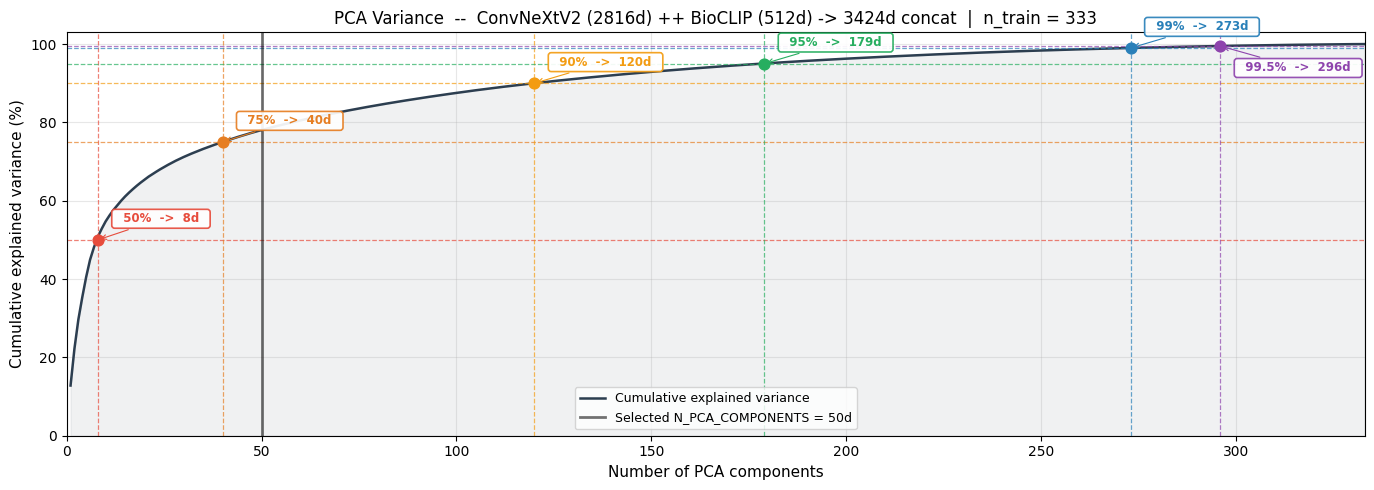

In [8]:
# =============================================================================
# CONCAT HYBRID MODEL: ConvNeXtV2 ++ BioCLIP -> (optional PCA) -> MLP
# =============================================================================
# Instead of training two separate classifiers, we concatenate the raw feature
# vectors from both backbones into one wide vector and feed a single MLP.
#
# ConvNeXtV2 (2816-d) ++ BioCLIP (512-d) ++ Color histogram = concat-d
#
# Optionally we can apply StandardScaler + PCA to reduce dimensionality first.
# Scaler and PCA are fitted on fold-training data only.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Settings ----------------------------------------------------------------

USE_PCA          = True    # True: scale -> PCA -> MLP | False: raw 2048-d -> MLP
N_PCA_COMPONENTS = 50     # components to keep when USE_PCA=True, Also based on K_FOLDS so there is a trade off for robustness and PCA resolution

CONCAT_CONVNEXT_FINETUNED = True   # set True after running FINE-TUNING


# --- Helper: PCA variance curve (visualisation only) -------------------------

def plot_pca_variance_curve(features, title, n_pca_selected=None):
    """Plot cumulative explained variance vs PCA components.
    Annotates 50/75/90/95/99/99.5 % thresholds and draws a line at n_pca_selected."""
    max_components = min(features.shape)
    print(f'Fitting PCA({max_components}) for variance plot...')

    viz_scaler = StandardScaler()
    viz_scaled = viz_scaler.fit_transform(features)
    viz_pca    = PCA(n_components=max_components, svd_solver='full')
    viz_pca.fit(viz_scaled)
    cum_var = np.cumsum(viz_pca.explained_variance_ratio_) * 100

    thresholds = [
        (50,   '#E74C3C', +4.5),
        (75,   '#E67E22', +4.5),
        (90,   '#F39C12', +4.5),
        (95,   '#27AE60', +4.5),
        (99,   '#2980B9', +4.5),
        (99.5, '#8E44AD', -6.5),
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    component_range = np.arange(1, max_components + 1)
    ax.plot(component_range, cum_var, lw=1.8,
            color='#2C3E50', label='Cumulative explained variance')
    ax.fill_between(component_range, cum_var, alpha=0.07, color='#2C3E50')

    for pct, color, y_off in thresholds:
        n_at = int(np.searchsorted(cum_var, pct)) + 1
        if n_at > max_components:
            continue
        ax.axhline(pct, color=color, lw=0.9, ls='--', alpha=0.7)
        ax.axvline(n_at, color=color, lw=0.9, ls='--', alpha=0.7)
        ax.scatter([n_at], [pct], color=color, s=60, zorder=5)
        min_x_offset = 3
        scaled_x_offset = max_components * 0.013
        if min_x_offset > scaled_x_offset:
            x_offset = min_x_offset
        else:
            x_offset = scaled_x_offset
        ax.annotate(
            f'  {pct}%  ->  {n_at}d  ',
            xy=(n_at, pct),
            xytext=(n_at + x_offset, pct + y_off),
            fontsize=8.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, alpha=0.92, linewidth=1.2),
            arrowprops=dict(arrowstyle='->', color=color, lw=0.8),
        )

    if n_pca_selected is not None:
        ax.axvline(n_pca_selected, color='black', lw=2.0, ls='-', alpha=0.55,
                   label=f'Selected N_PCA_COMPONENTS = {n_pca_selected}d')

    ax.set_xlabel('Number of PCA components', fontsize=11)
    ax.set_ylabel('Cumulative explained variance (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, max_components)
    ax.set_ylim(0, 103)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('pca_variance_concat.png', dpi=150, bbox_inches='tight')
    plt.show()



# load the base features
if CONCAT_CONVNEXT_FINETUNED:
    convnext_finetune_tag = '_ft'
else:
    convnext_finetune_tag = ''

convnext_features_file = f'Data\\task2_data\\t2_train_features{convnext_finetune_tag}_{FEATURE_EXTRACTOR}.pt'
convnext_features_pt = torch.load(
    convnext_features_file,
    weights_only=False,
)
bio_features_pt = torch.load(
    'Data\\task2_data\\t2_train_features_bioclip.pt',
    weights_only=False,
)

concat_labels         = convnext_features_pt['labels'].numpy()
convnext_features_raw = convnext_features_pt['features']
convnext_features     = np.asarray(convnext_features_raw, dtype=np.float32)
bio_features_raw      = bio_features_pt['features']
bio_features          = np.asarray(bio_features_raw, dtype=np.float32)

# Load color histogram features (aligned to backbone ordering)
color_concat_pt           = torch.load(r'Data\task2_data\t2_train_color_histogram.pt', weights_only=False)
color_concat_features_raw = color_concat_pt['features']
color_concat_features     = np.asarray(color_concat_features_raw, dtype=np.float32)

# Stack all three feature vectors into one wide vector per image
concat_features   = np.concatenate([convnext_features, bio_features, color_concat_features], axis=1)
num_classes       = len(np.unique(concat_labels))
total_feature_dim = concat_features.shape[1]

convnext_dim = convnext_features.shape[1]
bio_dim      = bio_features.shape[1]
color_dim    = color_concat_features.shape[1]
num_samples  = len(concat_labels)
print(f'Concat: {convnext_dim}d (ConvNeXtV2) + {bio_dim}d (BioCLIP) + '
      f'{color_dim}d (Color) = '
      f'{total_feature_dim}d  |  {num_samples} samples  |  {num_classes} classes')


# --- PCA variance plot -------------------------------------------------------

if USE_PCA:
    pca_selected_arg = N_PCA_COMPONENTS
else:
    pca_selected_arg = None

plot_title = (f'PCA Variance  --  ConvNeXtV2 ({convnext_dim}d) ++ '
              f'BioCLIP ({bio_dim}d) '
              f'-> {total_feature_dim}d concat  |  n_train = {len(train_idx)}')

plot_pca_variance_curve(
    concat_features[train_idx],
    title=plot_title,
    n_pca_selected=pca_selected_arg,
)

## META-CLASSIFIER MODEL

In [9]:
# =============================================================================
# META-CLASSIFIER MODEL: ConvNeXtV2-proba + BioCLIP-proba + deltas -> meta-clf
# =============================================================================
# Instead of concatenating raw feature vectors, we train a small linear
# classifier on each model separately, collect their probability
# outputs, compute the per class delta, and then feed everything to a meta-
# classifier that learns which model to trust
#
# Method:
#   1. Get ConvNeXtV2 probs (N_FOLDS-fold, no leakage)
#   2. Get BIOclip probs  (N_FOLDS-fold, no leakage)
#   3. abs_delta  = |convnext_proba - bio_proba|
#   4. meta_features = [convnext_probs, bio_probs, delta]
#   5. Meta-classifier fitted on meta_features

from sklearn.base import clone


# --- Settings ----------------------------------------------------------------

META_USE_FINETUNED_CONVNEXT = True   # True after running FINE-TUNING
META_BASE_C              = 10.0    # LogReg C for the two base classifiers
META_N_FOLDS             = N_FOLDS # folds used for OOF base-proba generation

# which arms to include in the meta feature vector (any subset of the three below)
META_ARMS = ['convnext', 'bio', 'color']

# the base classifier used to generate probabilities for both ConvNeXtV2 and BioCLIP arms
meta_base_classifier = LogisticRegression(C=META_BASE_C, max_iter=2000, random_state=42)

# --- Helpers -----------------------------------------------------------------

# Gets a model's prediction on the all inputs, using stratified N-folds
# Each fold fits base_model on fold-train only
def oof_probs(features, labels, base_model, n_folds):

    kfold     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    n_classes = len(np.unique(labels))
    oof_array = np.zeros((len(labels), n_classes), dtype=np.float32)
    for tr_i, va_i in kfold.split(features, labels):
        fold_model = clone(base_model)
        fold_model.fit(features[tr_i], labels[tr_i])
        fold_probs = fold_model.predict_proba(features[va_i])
        oof_array[va_i] = fold_probs
    return oof_array

# Stack the probs of all active arms + all pairwise deltas together
def build_meta_features(arm_probs):
    pairs = []
    for i in range(len(arm_probs)):
        for j in range(i + 1, len(arm_probs)):
            delta = abs(arm_probs[i] - arm_probs[j])
            pairs.append(delta)
    all_arrays = []
    for probs in arm_probs:
        all_arrays.append(probs)
    for delta in pairs:
        all_arrays.append(delta)
    return np.column_stack(all_arrays)



# --- Load features -----------------------------------------------------------

if META_USE_FINETUNED_CONVNEXT:
    convnext_filename_tag = '_ft'
else:
    convnext_filename_tag = ''

convnext_features_file = f'Data\\task2_data\\t2_train_features{convnext_filename_tag}_{FEATURE_EXTRACTOR}.pt'
convnext_data = torch.load(
    convnext_features_file,
    weights_only=False,
)
bio_data = torch.load(
    'Data\\task2_data\\t2_train_features_bioclip.pt',
    weights_only=False,
)

all_labels            = np.asarray(convnext_data['labels'])
convnext_features_raw = convnext_data['features']
all_convnext_features = np.asarray(convnext_features_raw, dtype=np.float32)
bio_features_raw      = bio_data['features']
all_bio_features      = np.asarray(bio_features_raw, dtype=np.float32)

# restrict to the train / val split created in LOAD DATA
convnext_train_features = all_convnext_features[train_idx]
convnext_val_features   = all_convnext_features[val_idx]

bio_train_features  = all_bio_features[train_idx]
bio_val_features    = all_bio_features[val_idx]

meta_train_labels   = all_labels[train_idx]
meta_val_labels     = all_labels[val_idx]

n_classes_meta = len(np.unique(meta_train_labels))

# --- Restrict color histogram features to the train / val split --------------
all_color_features_array = np.asarray(all_color_features, dtype=np.float32)
color_train_features = all_color_features_array[train_idx]
color_val_features   = all_color_features_array[val_idx]

print(f'ConvNeXtV2 train={convnext_train_features.shape}  val={convnext_val_features.shape}')
print(f'BioCLIP train={bio_train_features.shape}   val={bio_val_features.shape}')
print(f'Color   train={color_train_features.shape}  val={color_val_features.shape}')
arms_string = str(META_ARMS)
print(f'ConvNeXtV2+BioCLIP+Color meta  active arms: {arms_string}')


# --- OOF base probabilities on train set -------------------------------------

if 'convnext' in META_ARMS:
    print(f'\nOOF base probs — DINOv2  ({META_N_FOLDS}-fold)...')
    convnext_oof_probs = oof_probs(convnext_train_features, meta_train_labels,
                                   meta_base_classifier, META_N_FOLDS)

if 'bio' in META_ARMS:
    print(f'OOF base probs — BioCLIP ({META_N_FOLDS}-fold)...')
    bio_oof_probs  = oof_probs(bio_train_features,  meta_train_labels,
                               meta_base_classifier, META_N_FOLDS)

if 'color' in META_ARMS:
    print(f'OOF base probs — Color   ({META_N_FOLDS}-fold)...')
    color_oof_probs = oof_probs(color_train_features, meta_train_labels,
                                meta_base_classifier, META_N_FOLDS)

# --- Build meta features -----------------------------------------------------

# collect OOF probs for each active arm in order, then build meta features
arm_oof = []
if 'convnext' in META_ARMS:
    arm_oof.append(convnext_oof_probs)
if 'bio' in META_ARMS:
    arm_oof.append(bio_oof_probs)
if 'color' in META_ARMS:
    arm_oof.append(color_oof_probs)

# these are the inputs the meta-classifier will be trained on (done in hyperparameter search)
meta_train_features = build_meta_features(arm_oof)
n_deltas = len(arm_oof) * (len(arm_oof) - 1) // 2
arms_joined = ', '.join(META_ARMS)
print(f'\nMeta-train features: {meta_train_features.shape}  '
      f'[{arms_joined} probs ({n_classes_meta}d each), '
      f'+ {n_deltas} pairwise delta(s) x {n_classes_meta}d]')

ConvNeXtV2 train=(333, 2816)  val=(84, 2816)
BioCLIP train=(333, 512)   val=(84, 512)
Color   train=(333, 96)  val=(84, 96)
ConvNeXtV2+BioCLIP+Color meta  active arms: ['convnext', 'bio', 'color']

OOF base probs — DINOv2  (2-fold)...
OOF base probs — BioCLIP (2-fold)...
OOF base probs — Color   (2-fold)...

Meta-train features: (333, 60)  [convnext, bio, color probs (10d each), + 3 pairwise delta(s) x 10d]


## HYPER PARAM SEARCH

In [11]:
# =============================================================================
# UNIFIED HYPERPARAMETER SEARCH
# =============================================================================
# Evaluates every candidate with N_FOLDS-fold stratified cross-validation.
# StandardScaler + PCA (when enabled) fitted only on fold-train data, so
# there is no information leakage between folds.
#
# YOU MUST:
#   SEARCH_BACKBONE -> run LOAD DATA first
#   SEARCH_CONCAT   -> run CONCAT HYBRID MODEL first
#   SEARCH_META     -> run META-CLASSIFIER MODEL first

from sklearn.base import clone   # clone() makes a fresh unfitted copy per fold

# What to search over
SEARCH_BACKBONE = True   # single ConvNeXtV2 features
SEARCH_CONCAT   = True    # raw or PCA-reduced ConvNeXtV2+BioCLIP concat features
SEARCH_META     = True   # meta-classifier (base LogReg on ConvNeXtV2+BioCLIP -> meta model)

# PCA settings for concat search (only used when SEARCH_CONCAT = True)
CONCAT_SEARCH_USE_PCA_OPTIONS  = [True, False]
CONCAT_SEARCH_N_PCA_COMPONENTS = [37, 113, 166]

# Which models to include
SEARCH_LOGREG = True
SEARCH_SVM    = True
SEARCH_MLP    = True
SEARCH_KNN    = True


# This function evaluates a given model with a given feature extractor mode, uses N-Folds for robustness
def cross_val_f1(model_or_params, labels, n_folds, mode,
                 features=None, use_pca=False, n_pca=None,
                 convnext_feats=None, bio_feats=None, color_feats=None, base_c=1.0):

    if mode == 'meta':
        split_ref = convnext_feats
    else:
        split_ref = features

    # get the folds
    kfold     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_f1s  = []

    # for each fold
    for tr_i, va_i in kfold.split(split_ref, labels):

        # labels of the fold's train and val split
        fold_train_lbl = labels[tr_i]
        fold_val_lbl   = labels[va_i]

        if mode == 'meta':
            # fit one base classifier per active arm on the fold's train set
            arm_feat_map = {'convnext': convnext_feats, 'bio': bio_feats, 'color': color_feats}
            arm_bases = {}
            for arm in META_ARMS:
                arm_clf = LogisticRegression(C=base_c, max_iter=2000, random_state=42)
                arm_bases[arm] = arm_clf

            for arm, base in arm_bases.items():
                arm_train_data = arm_feat_map[arm][tr_i]
                base.fit(arm_train_data, fold_train_lbl)

            # the features are now ready for a meta-classifer
            train_probs_list = []
            for arm, base in arm_bases.items():
                arm_train_data = arm_feat_map[arm][tr_i]
                train_probs_list.append(base.predict_proba(arm_train_data))
            fold_train = build_meta_features(train_probs_list)

            val_probs_list = []
            for arm, base in arm_bases.items():
                arm_val_data = arm_feat_map[arm][va_i]
                val_probs_list.append(base.predict_proba(arm_val_data))
            fold_val = build_meta_features(val_probs_list)

        else:

            # just copy over the features as is
            fold_train = features[tr_i].copy()
            fold_val   = features[va_i].copy()

            # if PCA is enabled, do that too
            if use_pca:
                fold_train, fold_val = apply_scaler_and_pca(fold_train, fold_val, n_pca)

        # mlp is a params dict, everything else is a sklearn object
        if isinstance(model_or_params, dict) and model_or_params.get('type') == 'mlp':

            # create, train, evaluate the model
            _, met = train_multilayer_perceptron(
                fold_train, fold_train_lbl, fold_val, fold_val_lbl,
                hidden_layers=model_or_params['hidden'],
                learning_rate=model_or_params['lr'],
                dropout=model_or_params['dropout'],
                activation=model_or_params['activation'],
            )

            # store the score
            fold_f1s.append(met['f1'])
        else:
            # create the model using a clean clone of the current model thats being tested
            m = clone(model_or_params)

            # fit the model
            fold_train_array = np.asarray(fold_train)
            fold_train_lbl_array = np.asarray(fold_train_lbl)
            m.fit(fold_train_array, fold_train_lbl_array)

            # predict, evaluate and then store the score
            fold_val_array = np.asarray(fold_val)
            preds = m.predict(fold_val_array)
            fold_score = f1_score(fold_val_lbl, preds, average='weighted', zero_division=0)
            fold_f1s.append(fold_score)

    # return avg f1 and its variance
    return float(np.mean(fold_f1s)), float(np.std(fold_f1s))


# Function builds the grid searches for all selected models
def build_candidates(layer_sizes=None):
    """Build (label, model_or_params) pairs for all enabled model families."""
    if layer_sizes is None:
        layer_sizes = [512, 1024, 2048]
    candidates = []

    if SEARCH_LOGREG:
        for C in [0.001, 0.01, 0.1, 1, 10, 100]:
            candidates.append((
                f'LogReg C={C}',
                LogisticRegression(C=C, max_iter=2000, random_state=42),
            ))

    if SEARCH_KNN:
        for k in [5, 10, 15, 20]:
            for metric in ['cosine', 'euclidean']:
                candidates.append((
                    f'kNN k={k} {metric}',
                    KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=8),
                ))

    if SEARCH_SVM:
        svm_grid = [
            {'kernel': ['linear'],  'C': [ 0.01, 0.1, 1, 10, 100]},
            {'kernel': ['rbf'],     'C': [0.01, 0.1, 1, 10, 100],
                                      'gamma': ['scale', 'auto']}
        ]
        for param_dict in ParameterGrid(svm_grid):
            sorted_items = sorted(param_dict.items())
            label_parts = []
            for param_key, param_val in sorted_items:
                label_parts.append(f'{param_key}={param_val}')
            label = '  '.join(label_parts)
            candidates.append((
                f'SVM {label}',
                SVC(decision_function_shape='ovr', random_state=42, **param_dict),
            ))

    if SEARCH_MLP:
        mlp_configs = []

        for size in layer_sizes:
            mlp_configs.append((size,))

        for h1 in layer_sizes:
            for h2 in layer_sizes:
                mlp_configs.append((h1, h2))

        for hidden in mlp_configs:
            for lr in [1e-2, 1e-4]:
                for dropout in [0.0, 0.5]:
                    for activation in [nn.ReLU, nn.GELU]:
                        candidates.append((
                            f'MLP {hidden} lr={lr} do={dropout} act={activation.__name__}',
                            {'type': 'mlp', 'hidden': hidden, 'lr': lr, 'dropout': dropout, 'activation': activation},
                        ))

    return candidates


# The actual hyperparameter search
def run_search(feature_sets, candidates, n_folds):

    all_results = []

    # for each featureset type (backbone, concat, meta)
    for entry in feature_sets:

        # settings based on what features are being used
        feat_label = entry[0]
        is_meta = isinstance(entry[1], str) and entry[1] == 'meta'
        if is_meta:
            labels = entry[5]
        else:
            labels = entry[2]
        n_cands    = len(candidates)

        # debug for confirmation
        print(f'\nSearching: {feat_label}  ({len(labels)} samples, {n_folds}-fold CV, {n_cands} candidates)')

        # for every model combination provided
        for i, (model_label, model_or_params) in enumerate(candidates, 1):

            # build, train, evaluate the model on given feature set
            if is_meta:
                meta_convnext_feats = entry[2]
                meta_bio_feats      = entry[3]
                meta_color_feats    = entry[4]
                meta_labels         = entry[5]
                mean_f1, std_f1 = cross_val_f1(model_or_params, meta_labels, n_folds, 'meta',
                                               convnext_feats=meta_convnext_feats,
                                               bio_feats=meta_bio_feats,
                                               color_feats=meta_color_feats)
            else:
                entry_features = entry[1]
                entry_labels   = entry[2]
                entry_use_pca  = entry[3]
                entry_n_pca    = entry[4]
                mean_f1, std_f1 = cross_val_f1(model_or_params, entry_labels, n_folds, 'standard',
                                               features=entry_features,
                                               use_pca=entry_use_pca,
                                               n_pca=entry_n_pca)

            print(f'  [{i:>3}/{n_cands}] {model_label:<40}  F1={mean_f1:.4f} +/- {std_f1:.4f}')

            # save the result
            result_row = {
                'features': feat_label,
                'model':    model_label,
                'mean_f1':  mean_f1,
                'std_f1':   std_f1,
            }
            all_results.append(result_row)

    results_frame = pd.DataFrame(all_results)
    sorted_results = results_frame.sort_values('mean_f1', ascending=False)
    return sorted_results


# =============================================================================
# Run the search
# =============================================================================
# backbone and raw-concat have large input dims  -> wider MLP layers [512, 1024, 2048]
# concat-PCA and meta have small input dims      -> smaller MLP layers [32, 96, 384]

large_sets = []   # backbone, concat-raw
small_sets = []   # concat-PCA, meta

if SEARCH_BACKBONE:
    all_features_array = np.asarray(train_features, dtype=np.float32)
    all_labels_array   = np.asarray(train_labels)
    search_feat        = all_features_array[search_idx]
    search_lbl         = all_labels_array[search_idx]

    suffix_stripped = feature_file_suffix.lstrip('_')
    large_sets.append((
        'backbone_' + suffix_stripped,
        search_feat, search_lbl, False, None,
    ))

if SEARCH_CONCAT:
    for use_pca in CONCAT_SEARCH_USE_PCA_OPTIONS:

        if use_pca:
            pca_values = CONCAT_SEARCH_N_PCA_COMPONENTS
        else:
            pca_values = [None]

        for n_pca in pca_values:
            if use_pca:
                feat_label = f'concat_pca{n_pca}'
            else:
                feat_label = 'concat_raw'

            concat_features_array  = np.asarray(concat_features, dtype=np.float32)
            concat_search_features = concat_features_array[search_idx]
            concat_search_labels   = concat_labels[search_idx]
            entry = (
                feat_label,
                concat_search_features, concat_search_labels,
                use_pca, n_pca,
            )

            if use_pca:
                small_sets.append(entry)
            else:
                large_sets.append(entry)

if SEARCH_META:
    meta_convnext_features_file = f'Data\\task2_data\\t2_train_features_ft_{FEATURE_EXTRACTOR}.pt'
    meta_convnext_pt = torch.load(meta_convnext_features_file, weights_only=False)
    meta_bio_pt      = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt', weights_only=False)

    meta_convnext_features_raw = meta_convnext_pt['features']
    meta_bio_features_raw      = meta_bio_pt['features']
    meta_labels_raw            = meta_convnext_pt['labels']

    meta_convnext_train = np.asarray(meta_convnext_features_raw, dtype=np.float32)[search_idx]
    meta_bio_train      = np.asarray(meta_bio_features_raw,      dtype=np.float32)[search_idx]
    meta_search_labels  = np.asarray(meta_labels_raw)[search_idx]

    # load color histogram features from the cache created in LOAD DATA
    meta_color_pt    = torch.load(r'Data\task2_data\t2_train_color_histogram.pt', weights_only=False)
    meta_color_raw   = meta_color_pt['features']
    meta_color_train = np.asarray(meta_color_raw, dtype=np.float32)[search_idx]
    small_sets.append(('meta_convnext+bio+color', 'meta', meta_convnext_train, meta_bio_train, meta_color_train, meta_search_labels))

all_dfs = []

if large_sets:
    all_dfs.append(run_search(large_sets, build_candidates(layer_sizes=[512, 1024, 2048]), N_FOLDS))
if small_sets:
    all_dfs.append(run_search(small_sets, build_candidates(layer_sizes=[128, 256, 512]), N_FOLDS))

results_df_unsorted = pd.concat(all_dfs)
results_df = results_df_unsorted.sort_values('mean_f1', ascending=False)

print('\nTop 50 results:')
top_50_results = results_df.head(50)
print(top_50_results.to_string(index=False))

# export the results
stripped_suffix = feature_file_suffix.strip('_')
results_csv_path = f'Data/task2_data/search_results_extended_{stripped_suffix}.csv'
results_df.to_csv(results_csv_path, index=False)

print('\nFull results saved to CSV.')


Searching: backbone_convnextv2  (333 samples, 2-fold CV, 125 candidates)
  [  1/125] LogReg C=0.001                            F1=0.9696 +/- 0.0183
  [  2/125] LogReg C=0.01                             F1=0.9819 +/- 0.0181
  [  3/125] LogReg C=0.1                              F1=0.9819 +/- 0.0181
  [  4/125] LogReg C=1                                F1=0.9788 +/- 0.0212
  [  5/125] LogReg C=10                               F1=0.9788 +/- 0.0212
  [  6/125] LogReg C=100                              F1=0.9788 +/- 0.0212
  [  7/125] kNN k=5 cosine                            F1=0.9472 +/- 0.0015
  [  8/125] kNN k=5 euclidean                         F1=0.9477 +/- 0.0081
  [  9/125] kNN k=10 cosine                           F1=0.9518 +/- 0.0122
  [ 10/125] kNN k=10 euclidean                        F1=0.9517 +/- 0.0060
  [ 11/125] kNN k=15 cosine                           F1=0.9470 +/- 0.0156
  [ 12/125] kNN k=15 euclidean                        F1=0.9358 +/- 0.0156
  [ 13/125] kNN k=20 cosin

## SUBMISSION

In [12]:
# =============================================================================
# SUBMISSION SETTINGS
# =============================================================================
# Pick a mode and a single classifier -- all modes share the same hyperparams.
#
#   SUBMISSION_MODE       : 'backbone' | 'hybrid_concat' | 'hybrid_meta'
#   SUBMISSION_CLASSIFIER : 'logreg' | 'svm' | 'knn' | 'mlp'
# concat_pca208   MLP (128, 128, 128) lr=0.0001 do=0.2
SUBMISSION_MODE       = 'hybrid_concat'
SUBMISSION_CLASSIFIER = 'knn'
N_FOLDS = 2
# --- Shared classifier hyperparameters (paste best values from search) -------
LOGREG_C          = 0.1

SVM_KERNEL        = 'linear'
SVM_C             = 10.0
SVM_GAMMA         = 'scale'

KNN_N_NEIGHBORS   = 20
KNN_METRIC        = 'cosine'


MLP_HIDDEN_LAYERS = (64, 128, 128)
MLP_DROPOUT       = 0.0
MLP_EPOCHS        = 200
MLP_LR            = 0.01
MLP_ACTIVATION    = nn.GELU


# --- Mode-specific settings --------------------------------------------------
# backbone
BACKBONE_USE_FINETUNED = True   # True after FINE-TUNING

# hybrid_concat
CONCAT_CONVNEXT_FINETUNED = True   # True after FINE-TUNING
CONCAT_USE_PCA         = True
CONCAT_PCA_COMPONENTS  = 113

# hybrid_meta  (base classifiers are always LogReg; SUBMISSION_CLASSIFIER is the meta layer)
META_CONVNEXT_FINETUNED   = True   # True after FINE-TUNING
META_SUBMISSION_BASE_C = 10.0
META_ARMS              = ['convnext', 'bio', 'color']   # arms to include in meta feature vector

sorted_class_names = []
for class_idx in sorted(index_to_class):
    sorted_class_names.append(index_to_class[class_idx])

In [ ]:
# =============================================================================
# SUBMISSION
# =============================================================================
# Trains on the full dataset and writes t2_submission.csv.
# All three modes share fit_submission_classifier() -- change SUBMISSION_CLASSIFIER
# in SUBMISSION SETTINGS to swap the model without touching this cell.
#
# Run LOAD DATA and SUBMISSION SETTINGS first.


# --- Load features for a given mode ------------------------------------------

def load_train_features_for_submission():

    if SUBMISSION_MODE == 'backbone':
        if BACKBONE_USE_FINETUNED:
            tag = '_ft'
        else:
            tag = ''
        feature_file = f'Data\\task2_data\\t2_train_features{tag}_{FEATURE_EXTRACTOR}.pt'
        pt = torch.load(feature_file, weights_only=False)
        feature_array = np.asarray(pt['features'], np.float32)
        label_array   = np.asarray(pt['labels'])
        return feature_array, label_array, 'standard'

    elif SUBMISSION_MODE == 'hybrid_concat':
        if CONCAT_CONVNEXT_FINETUNED:
            tag = '_ft'
        else:
            tag = ''
        dino_file  = f'Data\\task2_data\\t2_train_features{tag}_{FEATURE_EXTRACTOR}.pt'
        dino_pt    = torch.load(dino_file, weights_only=False)
        bio_pt     = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt', weights_only=False)
        color_pt   = torch.load(r'Data\task2_data\t2_train_color_histogram.pt', weights_only=False)
        dino_array  = np.asarray(dino_pt['features'],  np.float32)
        bio_array   = np.asarray(bio_pt['features'],   np.float32)
        color_array = np.asarray(color_pt['features'], np.float32)
        feat = np.concatenate([dino_array, bio_array, color_array], axis=1)
        label_array = np.asarray(dino_pt['labels'])
        return feat, label_array, 'standard'

    elif SUBMISSION_MODE == 'hybrid_meta':
        if META_CONVNEXT_FINETUNED:
            tag = '_ft'
        else:
            tag = ''
        dino_file = f'Data\\task2_data\\t2_train_features{tag}_{FEATURE_EXTRACTOR}.pt'
        dino_pt   = torch.load(dino_file, weights_only=False)
        bio_pt    = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt', weights_only=False)
        dino_array  = np.asarray(dino_pt['features'], np.float32)
        bio_array   = np.asarray(bio_pt['features'],  np.float32)

        # load color histogram features from the cache created in LOAD DATA
        color_pt    = torch.load(r'Data\task2_data\t2_train_color_histogram.pt', weights_only=False)
        color_array = np.asarray(color_pt['features'], np.float32)

        label_array = np.asarray(dino_pt['labels'])
        return (dino_array, bio_array, color_array), label_array, 'meta'


# --- Create the selected classifier model ------------------------------------

def submission_model_candidate():
    clf = SUBMISSION_CLASSIFIER

    if clf == 'logreg':
        return LogisticRegression(C=LOGREG_C, max_iter=2000, random_state=42)

    if clf == 'svm':
        return SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                   decision_function_shape='ovr', random_state=42)

    if clf == 'knn':
        return KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, metric=KNN_METRIC, n_jobs=-1)

    if clf == 'mlp':
        return {'type': 'mlp', 'hidden': MLP_HIDDEN_LAYERS, 'lr': MLP_LR,
                'dropout': MLP_DROPOUT, 'activation': MLP_ACTIVATION}


# --- Fit the chosen classifier on train_feat and return a predict callable ---

def fit_submission_classifier(train_feat, train_lbl):
    """Fit the classifier chosen by SUBMISSION_CLASSIFIER; return predict(test_feat)."""
    clf = SUBMISSION_CLASSIFIER

    if clf == 'logreg':
        m = LogisticRegression(C=LOGREG_C, max_iter=2000, random_state=42)
        m.fit(train_feat, train_lbl)
        return m.predict

    elif clf == 'svm':
        m = SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA,
                decision_function_shape='ovr', random_state=42)
        m.fit(train_feat, train_lbl)
        return m.predict

    elif clf == 'knn':
        m = KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS, metric=KNN_METRIC, n_jobs=-1)
        m.fit(train_feat, train_lbl)
        return m.predict

    elif clf == 'mlp':
        # Hold out 20% for early stopping
        X_fit, X_es, y_fit, y_es = train_test_split(
            train_feat.astype(np.float32), train_lbl,
            test_size=0.2, random_state=42, stratify=train_lbl,
        )
        model, _ = train_multilayer_perceptron(
            X_fit, y_fit, X_es, y_es,
            hidden_layers=MLP_HIDDEN_LAYERS, activation=MLP_ACTIVATION,
            dropout=MLP_DROPOUT, epochs=MLP_EPOCHS, learning_rate=MLP_LR,
        )
        model.eval()
        dev = next(model.parameters()).device
        def predict_with_mlp(feat):
            feat_float = feat.astype(np.float32)
            feat_tensor_raw = torch.tensor(feat_float)
            feat_tensor = feat_tensor_raw.to(dev)
            with torch.no_grad():
                logits = model(feat_tensor)
                argmax_output = logits.argmax(1)
                cpu_output    = argmax_output.cpu()
                predictions   = cpu_output.numpy()
            return predictions
        return predict_with_mlp

    else:
        raise ValueError(f'Unknown SUBMISSION_CLASSIFIER: {clf!r}')


# --- backbone ----------------------------------------------------------------

def generate_backbone_submission():
    if BACKBONE_USE_FINETUNED:
        feat_tag = '_ft'
    else:
        feat_tag = ''
    tr_pt      = torch.load(f'Data\\task2_data\\t2_train_features{feat_tag}_{FEATURE_EXTRACTOR}.pt', weights_only=False)
    te_pt      = torch.load(f'Data\\task2_data\\t2_test_features{feat_tag}_{FEATURE_EXTRACTOR}.pt',  weights_only=False)
    train_feat = np.asarray(tr_pt['features'], np.float32)
    train_lbl  = np.asarray(tr_pt['labels'])
    test_feat  = np.asarray(te_pt['features'], np.float32)
    print(f'[backbone{feat_tag}]  train={train_feat.shape}  test={test_feat.shape}')
    predict   = fit_submission_classifier(train_feat, train_lbl)
    image_ids = []
    for path in te_pt['paths']:
        basename    = os.path.basename(path)
        name_no_ext = os.path.splitext(basename)[0]
        image_ids.append(name_no_ext)
    return predict(test_feat), image_ids


# --- hybrid_concat -----------------------------------------------------------

def generate_concat_submission():
    if CONCAT_CONVNEXT_FINETUNED:
        convnext_tag = '_ft'
    else:
        convnext_tag = ''
    convnext_tr  = torch.load(f'Data\\task2_data\\t2_train_features{convnext_tag}_{FEATURE_EXTRACTOR}.pt', weights_only=False)
    bio_tr       = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt',            weights_only=False)
    color_tr     = torch.load(r'Data\task2_data\t2_train_color_histogram.pt',               weights_only=False)
    convnext_te  = torch.load(f'Data\\task2_data\\t2_test_features{convnext_tag}_{FEATURE_EXTRACTOR}.pt',   weights_only=False)
    bio_te       = torch.load('Data\\task2_data\\t2_test_features_bioclip.pt',              weights_only=False)
    color_te     = torch.load(r'Data\task2_data\t2_test_color_histogram.pt',                weights_only=False)

    convnext_tr_array = np.asarray(convnext_tr['features'], np.float32)
    bio_tr_array      = np.asarray(bio_tr['features'],      np.float32)
    color_tr_array    = np.asarray(color_tr['features'],    np.float32)
    train_feat = np.concatenate([convnext_tr_array, bio_tr_array, color_tr_array], axis=1)

    convnext_te_array = np.asarray(convnext_te['features'], np.float32)
    bio_te_array      = np.asarray(bio_te['features'],      np.float32)
    color_te_array    = np.asarray(color_te['features'],    np.float32)
    test_feat  = np.concatenate([convnext_te_array, bio_te_array, color_te_array], axis=1)
    train_lbl  = np.asarray(convnext_tr['labels'])

    if CONCAT_USE_PCA:
        train_feat, test_feat = apply_scaler_and_pca(train_feat, test_feat, CONCAT_PCA_COMPONENTS)

    if CONCAT_USE_PCA:
        dim_str = f'PCA({CONCAT_PCA_COMPONENTS}d)'
    else:
        dim_str = f'raw({train_feat.shape[1]}d)'
    print(f'[concat{convnext_tag}  {dim_str}]  train={train_feat.shape}  test={test_feat.shape}')
    predict   = fit_submission_classifier(train_feat, train_lbl)
    image_ids = []
    for path in convnext_te['paths']:
        basename    = os.path.basename(path)
        name_no_ext = os.path.splitext(basename)[0]
        image_ids.append(name_no_ext)
    return predict(test_feat), image_ids


# --- hybrid_meta -------------------------------------------------------------

def generate_meta_submission():
    from sklearn.base import clone as sk_clone
    if META_CONVNEXT_FINETUNED:
        convnext_tag = '_ft'
    else:
        convnext_tag = ''
    convnext_tr_file = f'Data\\task2_data\\t2_train_features{convnext_tag}_{FEATURE_EXTRACTOR}.pt'
    convnext_te_file = f'Data\\task2_data\\t2_test_features{convnext_tag}_{FEATURE_EXTRACTOR}.pt'
    convnext_tr = torch.load(convnext_tr_file, weights_only=False)
    bio_tr      = torch.load('Data\\task2_data\\t2_train_features_bioclip.pt',            weights_only=False)
    convnext_te = torch.load(convnext_te_file,                                                weights_only=False)
    bio_te      = torch.load('Data\\task2_data\\t2_test_features_bioclip.pt',              weights_only=False)

    convnext_train = np.asarray(convnext_tr['features'], np.float32)
    bio_train      = np.asarray(bio_tr['features'],  np.float32)
    convnext_test  = np.asarray(convnext_te['features'], np.float32)
    bio_test       = np.asarray(bio_te['features'],  np.float32)
    train_lbl      = np.asarray(convnext_tr['labels'])

    # load color histogram features from the caches created in LOAD DATA
    color_tr    = torch.load(r'Data\task2_data\t2_train_color_histogram.pt', weights_only=False)
    color_te    = torch.load(r'Data\task2_data\t2_test_color_histogram.pt',  weights_only=False)
    color_train = np.asarray(color_tr['features'], np.float32)
    color_test  = np.asarray(color_te['features'], np.float32)

    arm_train = {'convnext': convnext_train, 'bio': bio_train, 'color': color_train}
    arm_test  = {'convnext': convnext_test,  'bio': bio_test,  'color': color_test}

    # OOF base probabilities for meta-classifier training (no leakage)
    base_proto = LogisticRegression(C=META_SUBMISSION_BASE_C, max_iter=2000, random_state=42)
    print(f'[meta{convnext_tag}]  OOF base proba ({N_FOLDS}-fold)...')

    arm_oof  = {}
    arm_full = {}
    for arm in META_ARMS:
        arm_oof[arm]    = oof_probs(arm_train[arm], train_lbl, base_proto, N_FOLDS)
        # Full base model for test-set probabilities
        base_full       = sk_clone(base_proto)
        base_full.fit(arm_train[arm], train_lbl)
        arm_full[arm]   = base_full.predict_proba(arm_test[arm])

    oof_list  = []
    full_list = []
    for arm in META_ARMS:
        oof_list.append(arm_oof[arm])
        full_list.append(arm_full[arm])
    meta_train_feat = build_meta_features(oof_list)
    meta_test_feat  = build_meta_features(full_list)

    print(f'  meta_train={meta_train_feat.shape}  meta_test={meta_test_feat.shape}')
    predict   = fit_submission_classifier(meta_train_feat, train_lbl)
    image_ids = []
    for path in convnext_te['paths']:
        basename    = os.path.basename(path)
        name_no_ext = os.path.splitext(basename)[0]
        image_ids.append(name_no_ext)
    return predict(meta_test_feat), image_ids


# --- Dispatch ----------------------------------------------------------------

submission_modes = {
    'backbone':      generate_backbone_submission,
    'hybrid_concat': generate_concat_submission,
    'hybrid_meta':   generate_meta_submission,
}
if SUBMISSION_MODE not in submission_modes:
    valid_modes = list(submission_modes)
    raise ValueError(f'Unknown SUBMISSION_MODE {SUBMISSION_MODE!r}. Choose from: {valid_modes}')

print(f'Training {SUBMISSION_MODE} / {SUBMISSION_CLASSIFIER} on all {len(train_labels)} labelled samples...')
predictions, image_ids = submission_modes[SUBMISSION_MODE]()

submission = pd.DataFrame({'image_id': image_ids, 'class_id': predictions})
submission.to_csv('t2_submission.csv', index=False)
print(f'Saved {len(submission)} predictions to t2_submission.csv')

Training hybrid_concat / knn on all 417 labelled samples...
[concat_ft  PCA(113d)]  train=(417, 113)  test=(180, 113)
Saved 180 predictions to t2_submission.csv


## ERROR ANALYSIS

[error analysis] Fine-tuned features -- fit on train_idx, eval on val_idx
Error analysis  mode=hybrid_concat  clf=knn  (val split  n=84)
  F1=1.0000  Acc=1.0000


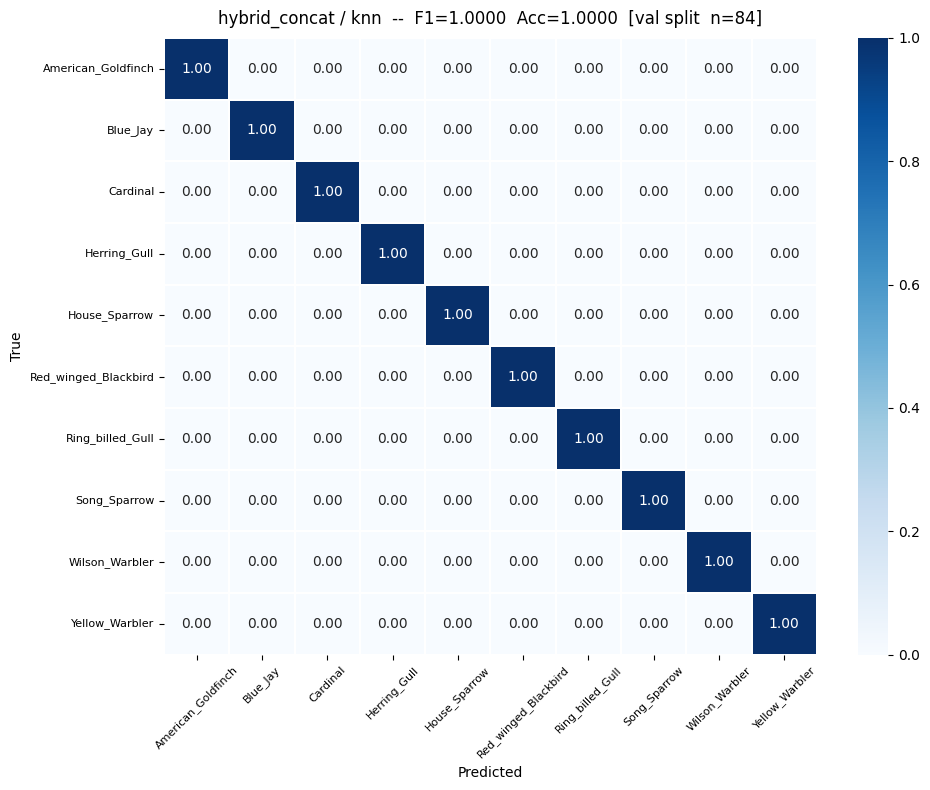


  PER-CLASS F1  (worst -> best)
  Class                               F1   Support
  ---------------------------------------------------
  American_Goldfinch              1.0000         8
  Blue_Jay                        1.0000         8
  Cardinal                        1.0000         8
  Herring_Gull                    1.0000         9
  House_Sparrow                   1.0000         9
  Red_winged_Blackbird            1.0000         9
  Ring_billed_Gull                1.0000         8
  Song_Sparrow                    1.0000         9
  Wilson_Warbler                  1.0000         8
  Yellow_Warbler                  1.0000         8

  Class: American_Goldfinch            F1=1.0000  errors=0/8
  :)  Model got every sample in this class correct!

  Class: Blue_Jay                      F1=1.0000  errors=0/8
  :)  Model got every sample in this class correct!

  Class: Cardinal                      F1=1.0000  errors=0/8
  :)  Model got every sample in this class correct!

  Class: 

In [14]:
# =============================================================================
# ERROR ANALYSIS
# =============================================================================
# Uses the model and hyperparameters from SUBMISSION SETTINGS to fit on
# train_idx and evaluate on val_idx -- the same canonical 80/20 split
# used throughout the pipeline.
#
# Run LOAD DATA and SUBMISSION first.
#
# Leakage handling:
#   Both frozen and fine-tuned features use the same protocol: fit on
#   train_idx, evaluate on val_idx.  val_idx is held out from both
#   fine-tuning and classifier training, so scores are honest for
#   both feature types.

import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report

# max misclassified images to show per class
IMAGES_PER_CLASS = 10


# --- Load features and build classifier candidate ----------------------------

feat_data, ea_labels, val_mode = load_train_features_for_submission()
model_cand = submission_model_candidate()

use_pca   = SUBMISSION_MODE == 'hybrid_concat' and CONCAT_USE_PCA
if use_pca:
    n_pca = CONCAT_PCA_COMPONENTS
else:
    n_pca = None
if SUBMISSION_MODE == 'hybrid_meta':
    base_c = META_SUBMISSION_BASE_C
else:
    base_c = 1.0

class_names = []
for class_idx in sorted(index_to_class):
    class_names.append(index_to_class[class_idx])
n_classes   = len(class_names)


# --- Per-split fit/predict (mirrors submission logic) ------------------------

def ea_fit_predict(tr_i, va_i):
    fold_train_lbl = ea_labels[tr_i]
    fold_val_lbl   = ea_labels[va_i]

    if val_mode == 'meta':
        arm_feat_map = {
            'convnext': feat_data[0],
            'bio':      feat_data[1],
            'color':    feat_data[2],
        }
        # OOF probs for train split (no in-sample leakage)
        base_proto = LogisticRegression(C=base_c, max_iter=2000, random_state=42)
        from sklearn.base import clone as local_clone
        arm_oof_tr = {}
        for arm in META_ARMS:
            arm_train_data = arm_feat_map[arm][tr_i]
            arm_oof_tr[arm] = oof_probs(arm_train_data, fold_train_lbl, base_proto, META_N_FOLDS)

        # full base classifiers trained on tr_i to generate val probs
        arm_bases = {}
        for arm in META_ARMS:
            arm_bases[arm] = local_clone(base_proto)
        for arm, base in arm_bases.items():
            arm_train_data = arm_feat_map[arm][tr_i]
            base.fit(arm_train_data, fold_train_lbl)

        oof_list = []
        for arm in META_ARMS:
            oof_list.append(arm_oof_tr[arm])
        fold_train = build_meta_features(oof_list)

        val_probs_list = []
        for arm in META_ARMS:
            arm_val_data = arm_feat_map[arm][va_i]
            val_probs_list.append(arm_bases[arm].predict_proba(arm_val_data))
        fold_val = build_meta_features(val_probs_list)
    else:
        fold_train = feat_data[tr_i].copy()
        fold_val   = feat_data[va_i].copy()
        if use_pca:
            fold_train, fold_val = apply_scaler_and_pca(fold_train, fold_val, n_pca)

    if isinstance(model_cand, dict) and model_cand.get('type') == 'mlp':
        p = model_cand
        model, _ = train_multilayer_perceptron(
            fold_train, fold_train_lbl, fold_val, fold_val_lbl,
            hidden_layers=p['hidden'], learning_rate=p['lr'],
            dropout=p['dropout'], activation=p['activation'],
        )
        model.eval()
        dev = next(model.parameters()).device
        fold_val_float = fold_val.astype(np.float32)
        fold_val_tensor_raw = torch.tensor(fold_val_float)
        fold_val_tensor = fold_val_tensor_raw.to(dev)
        with torch.no_grad():
            logits         = model(fold_val_tensor)
            argmax_output  = logits.argmax(1)
            cpu_output     = argmax_output.cpu()
            preds          = cpu_output.numpy()
    else:
        m = clone(model_cand)
        fold_train_array = np.asarray(fold_train)
        fold_train_lbl_array = np.asarray(fold_train_lbl)
        m.fit(fold_train_array, fold_train_lbl_array)
        fold_val_array = np.asarray(fold_val)
        preds = m.predict(fold_val_array)

    return preds


# =============================================================================
# EVALUATION  (fit on train_idx, evaluate on val_idx)
# =============================================================================

finetuned_backbone = any([BACKBONE_USE_FINETUNED, CONCAT_CONVNEXT_FINETUNED, META_CONVNEXT_FINETUNED])
if finetuned_backbone:
    feature_type_label = 'Fine-tuned'
else:
    feature_type_label = 'Frozen'
print(f'[error analysis] {feature_type_label} features -- fit on train_idx, eval on val_idx')
print(f'Error analysis  mode={SUBMISSION_MODE}  clf={SUBMISSION_CLASSIFIER}  (val split  n={len(val_idx)})')

preds       = ea_fit_predict(train_idx, val_idx)
eval_idx    = val_idx
eval_labels = ea_labels[val_idx]
eval_preds  = preds
split_label = f'val split  n={len(val_idx)}'

oof_f1  = f1_score(eval_labels, eval_preds, average='weighted', zero_division=0)
oof_acc = accuracy_score(eval_labels, eval_preds)
print(f'  F1={oof_f1:.4f}  Acc={oof_acc:.4f}')


# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm         = confusion_matrix(eval_labels, eval_preds)
cm_float   = cm.astype(float)
cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_norm    = cm_float / cm_row_sum

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.3)

plot_title = f'{SUBMISSION_MODE} / {SUBMISSION_CLASSIFIER}  --  F1={oof_f1:.4f}  Acc={oof_acc:.4f}  [{split_label}]'
ax.set_title(
    plot_title,
    pad=10,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()